In [1]:
import sys
sys.path.append("../src")
import numpy as np
import pandas as pd
import torch
import matplotlib.pylab as plt
from synthetic_observations import Observations
from gaussian_synthetic_observations import Gaussian_Observations
from transformer import *
from spectrum_lsf import Score_Likelihood
from score_models import ScoreModel
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from template import Template
from sbart_rv_finder import RV_Retrieval
from mala import MALA

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
change_res=True

In [19]:
%reload_ext autoreload

In [26]:
samples = []
templateseedrv = []
intseedrv = []
ogseedrv = []
seeds = np.arange(25)
for s in seeds:
    snr = 200
    N = 5
    obs = Observations(i=0,SNR=snr,filepath='../data/sSPIRou20_val.df',N=N,seed=s)
    synthetic_spectra, uncertainty = obs.make_observations(func='connors',add_RV=True,change_res=change_res)
    synthetic_spectra, uncertainty = obs.post_process()
    non_ones = torch.where(obs.padded_wgrid!=1)

    # Create template
    temp = Template(synthetic_spectra[:,:],obs.berv[:],obs.inst_wgrid,obs.wgrid)
    template = temp.make_template(func='scipy')
    sbart = RV_Retrieval(snr,template,obs.wgrid,obs.inst_wgrid,N)
    templatervs, uncs = sbart.find_dv(synthetic_spectra[:,:].cpu(),uncertainty.cpu()[:,:],obs.berv[:].cpu(),func='connors')
    print(template.shape,obs.training[0,0].shape)
    sbart = RV_Retrieval(snr,obs.training[0,0][non_ones[0][0]:non_ones[0][-1]+1],obs.wgrid,obs.inst_wgrid,N,type='sample')
    intrvs, uncs = sbart.find_dv(synthetic_spectra[:,:].cpu(),uncertainty.cpu()[:,:],obs.berv[:].cpu(),func='connors')

    sbart = RV_Retrieval(snr,obs.original_spectrum[0,0],obs.wgrid,obs.inst_wgrid,N,type='intrinsic')
    ogrvs, uncs = sbart.find_dv(synthetic_spectra[:,:].cpu(),uncertainty.cpu()[:,:],obs.berv[:].cpu(),func='connors')

    mala = MALA(synthetic_spectra[:,:],uncertainty[:,:],obs.berv,snr,obs.inst_wgrid,obs.wgrid)

    init_rvs = obs.planet.unsqueeze(0).expand(1,N)
    init_rvs = torch.tensor(templatervs).to(DEVICE).unsqueeze(0).expand(1,N)
    
    samples_int, accepted_int = mala.find_rv(init_rvs,obs.training.repeat(1,1,1)[:,:,non_ones[0][0]:non_ones[0][-1]+1],2000)
    samples.append(samples_int)
    templateseedrv.append(templatervs)
    intseedrv.append(intrvs)
    ogseedrv.append(ogrvs)
    print(s)

torch.Size([5])
torch.Size([18681]) torch.Size([18688])
0
torch.Size([5])
torch.Size([18681]) torch.Size([18688])
1
torch.Size([5])
torch.Size([18681]) torch.Size([18688])
2
torch.Size([5])
torch.Size([18681]) torch.Size([18688])
3
torch.Size([5])
torch.Size([18681]) torch.Size([18688])
4
torch.Size([5])
torch.Size([18681]) torch.Size([18688])
5
torch.Size([5])
torch.Size([18681]) torch.Size([18688])
6
torch.Size([5])
torch.Size([18681]) torch.Size([18688])
7
torch.Size([5])
torch.Size([18681]) torch.Size([18688])
8
torch.Size([5])
torch.Size([18681]) torch.Size([18688])
9
torch.Size([5])
torch.Size([18681]) torch.Size([18688])
10
torch.Size([5])
torch.Size([18681]) torch.Size([18688])
11
torch.Size([5])
torch.Size([18681]) torch.Size([18688])
12
torch.Size([5])
torch.Size([18681]) torch.Size([18688])
13
torch.Size([5])
torch.Size([18681]) torch.Size([18688])
14
torch.Size([5])
torch.Size([18681]) torch.Size([18688])
15
torch.Size([5])
torch.Size([18681]) torch.Size([18688])
16
torch.S

In [27]:
obs.training.shape

torch.Size([1, 1, 18688])

In [28]:
samples = torch.stack(samples).cpu().numpy()

In [29]:
seedtemp = np.array(templateseedrv)
seedint = np.array(intseedrv)
ogseed = np.array(ogseedrv)

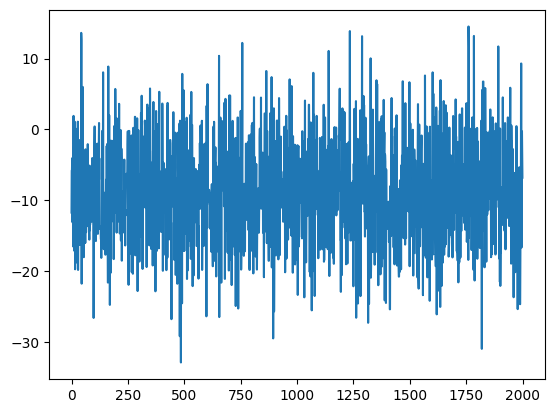

In [30]:
plt.plot(samples[0,:,0,0])

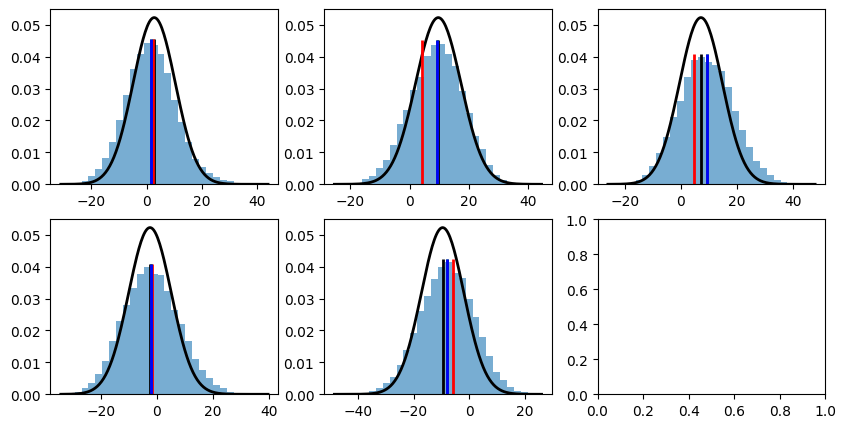

In [32]:
from scipy.stats import norm

fix, axs = plt.subplots(2,3,figsize=(10,5))
axs = axs.flatten()  # Flatten to easily index from 0 to 8
for i in range(N):
    n, bins,_ = axs[i].hist(samples[:,500:,0,i].flatten(),density=True,alpha=0.6,bins=30)

    # Gaussian curve
    x = np.linspace(bins[0], bins[-1], 200)  # smooth x-axis
    y = norm.pdf(x, obs.planet[i].cpu(), mala.deltaV)  # PDF values
    axs[i].plot(x, y, 'k-', linewidth=2)

    axs[i].vlines(obs.planet[i].cpu(),0,max(n)+0.001,color="k",lw=2)
    axs[i].vlines(np.mean(seedtemp,axis=0)[i],0,max(n)+0.001,color="r",lw=2)
    axs[i].vlines(np.mean(seedint,axis=0)[i],0,max(n)+0.001,color="g",lw=2)
    axs[i].vlines(np.mean(ogseed,axis=0)[i],0,max(n)+0.001,color="b",lw=2)
    print(np.mean(seedint,axis=0)[i]-np.mean(ogseed,axis=0)[i])

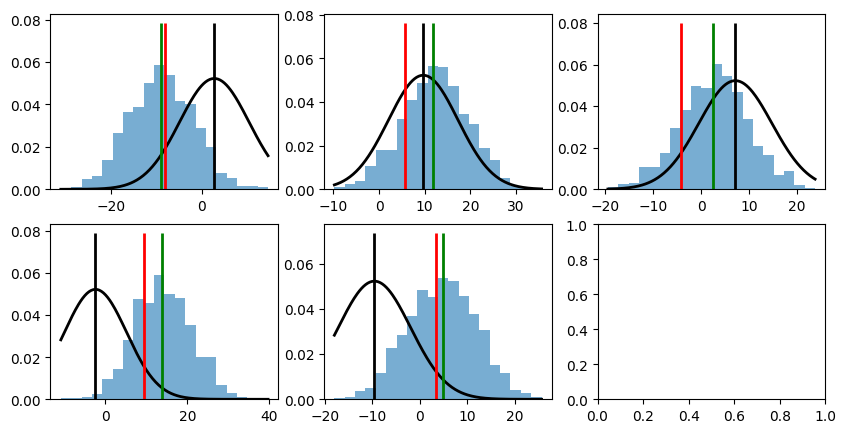

In [18]:
fix, axs = plt.subplots(2,3,figsize=(10,5))
axs = axs.flatten()  # Flatten to easily index from 0 to 8
seed = 0
for i in range(N):
    n, bins,_ = axs[i].hist(samples[seed,500:,0,i].flatten(),density=True,alpha=0.6,bins=20)
    # Gaussian curve
    x = np.linspace(bins[0], bins[-1], 200)  # smooth x-axis
    y = norm.pdf(x, obs.planet[i].cpu(), mala.deltaV)  # PDF values
    axs[i].plot(x, y, 'k-', linewidth=2)
    axs[i].vlines(obs.planet[i].cpu(),0,max(n)+0.02,color="k",lw=2)
    axs[i].vlines(seedtemp[seed,i],0,max(n)+0.02,color="r",lw=2)
    axs[i].vlines(seedint[seed,i],0,max(n)+0.02,color="g",lw=2)